# U-Net vs. DeepLabV3 Segmenter Comparison (Sequential Segment -> Mask -> Classify)

Compares two segmenters feeding the SAME masked-ResNet50 classifier, as a sequential
pipeline -- same pattern as `export_leaf_pipeline/` (which used DeepLabV3). This notebook
is purely additive: it does not modify `export_leaf_pipeline/`, the U-Net project, or
`resnet50_masked_comparison.ipynb`. Nothing is retrained here -- only existing checkpoints
are loaded and evaluated.

## Task 1 findings (paths + two real mismatches found and resolved)

**Paths** (confirmed by inspection, not assumed):
- U-Net export: `d:/Reasearch/Unet/export/` (`unet_tomato_final.pth`, `metadata.json`,
  `unet_lpf_extractor.py`) -- authoritative copy (newer metadata.json than the one already
  copied into `fusion_layer/inputs/`).
- Masked-ResNet50 classifier: `checkpoints_masked/resnet50_masked_best.pt` (this project;
  identical weights to `export_leaf_pipeline/resnet50_leaf_classifier.pth`).
- Test set: `tomato final dataset/test` (this project) -- verified **byte-identical** (md5)
  to the U-Net project's own copy of the same folder.
- DeepLabV3 reference pipeline: `export_leaf_pipeline/` (75.7% reported mean IoU, 85.0%
  full pipeline accuracy).

**Mismatch 1 -- IoU metrics aren't the same metric.** DeepLabV3's reported 75.7% is the
*average of background-class IoU and plant-class IoU* (background is trivially easy,
inflating the average). U-Net's reported 66.5% IoU / 75.7% Dice is *plant-class-only*
(read directly from `unet_pipeline_v2.ipynb`'s `iou_score()`/`dice_coeff()`). Resolution
(per user): recompute BOTH metrics for BOTH models here, on identical ground-truth masks,
so the table is honest.

**Mismatch 2 -- different image preprocessing.** U-Net's own pipeline does a *direct
resize* to 224x224 (`cv2.resize`, distorts aspect ratio) before predicting a mask -- not
the Resize(256)->CenterCrop(224) the classifier/DeepLabV3 pipeline expects. Applying a
mask predicted on one crop geometry to an image built with a different crop geometry
would silently misalign mask and plant. Resolution (per user): use U-Net's own
direct-resize frame as the shared frame for this whole pipeline (mask AND the image fed
to the classifier both come from the same direct-resize-to-224 image). This means the
classifier sees marginally different preprocessing than during its own training/eval --
accepted tradeoff for simplicity, and its effect will just show up honestly in the
accuracy number below.

In [1]:
import os
import json
import importlib.util
import random

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# ---- Resolved paths (see Task 1 findings above) ----
PROJECT_ROOT = r"d:\Reasearch\Resnet50test"
UNET_EXPORT_DIR = r"d:\Reasearch\Unet\export"
UNET_CKPT_PATH = os.path.join(UNET_EXPORT_DIR, "unet_tomato_final.pth")
UNET_LOADER_PATH = os.path.join(UNET_EXPORT_DIR, "unet_lpf_extractor.py")

CLASSIFIER_CKPT_PATH = os.path.join(PROJECT_ROOT, "checkpoints_masked", "resnet50_masked_best.pt")

DEEPLABV3_CKPT_PATH = os.path.join(PROJECT_ROOT, "checkpoints_segmentation", "deeplabv3_leaf_seg_best.pt")
DEEPLABV3_EXPORT_DIR = os.path.join(PROJECT_ROOT, "export_leaf_pipeline")

TEST_DIR = os.path.join(PROJECT_ROOT, "tomato final dataset", "test")
TEST_COCO_JSON = os.path.join(TEST_DIR, "_annotations.coco.json")

CLASS_NAMES = ["developing", "flowering", "fruiting", "seeding"]
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

for p in [UNET_CKPT_PATH, UNET_LOADER_PATH, CLASSIFIER_CKPT_PATH, DEEPLABV3_CKPT_PATH, TEST_COCO_JSON]:
    assert os.path.exists(p), f"missing: {p}"
print("All resolved paths exist.")

All resolved paths exist.


## Fair-comparison metric functions

`foreground_iou_dice` matches U-Net's own `iou_score`/`dice_coeff` exactly (plant-class
only). `both_class_mean_iou` matches how DeepLabV3's 75.7% was originally computed
(average of background-class IoU and plant-class IoU). Both are computed for both models
below.

In [3]:
def foreground_iou_dice(pred_binary, target_binary, eps=1e-6):
    """pred_binary, target_binary: numpy arrays, same shape, values in {0,1}. Plant-class-only,
    matching Unet/unet_pipeline_v2.ipynb's iou_score()/dice_coeff() exactly."""
    pred = pred_binary.astype(np.float32).flatten()
    target = target_binary.astype(np.float32).flatten()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)
    return float(iou), float(dice)


def both_class_mean_iou(pred_binary, target_binary):
    """Average of background-class IoU and plant-class IoU, matching leaf_segmentation.ipynb's
    mean_iou() (how DeepLabV3's 75.7% was originally reported)."""
    ious = []
    for c in (0, 1):
        pred_c = pred_binary == c
        target_c = target_binary == c
        intersection = np.logical_and(pred_c, target_c).sum()
        union = np.logical_or(pred_c, target_c).sum()
        if union == 0:
            continue
        ious.append(intersection / union)
    return float(sum(ious) / len(ious)) if ious else 0.0

## Load U-Net (reused exactly as provided, no reimplementation)

Imports `UNet` + `load_unet` directly from the U-Net project's own
`unet_lpf_extractor.py` by file path.

In [4]:
spec = importlib.util.spec_from_file_location("unet_lpf_extractor", UNET_LOADER_PATH)
unet_lpf_extractor = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unet_lpf_extractor)

unet_model = unet_lpf_extractor.load_unet(UNET_CKPT_PATH, device=device)
print("U-Net loaded. Params:", sum(p.numel() for p in unet_model.parameters()))
print("U-Net expected threshold:", unet_lpf_extractor.MASK_THRESHOLD, "| img size:", unet_lpf_extractor.IMG_SIZE)

U-Net loaded. Params: 7765985
U-Net expected threshold: 0.5 | img size: 224


## Load the masked-trained ResNet50 classifier (91.87% oracle-mask accuracy)

In [5]:
classifier = models.resnet50(weights=None)
classifier.fc = nn.Linear(classifier.fc.in_features, len(CLASS_NAMES))
clf_state = torch.load(CLASSIFIER_CKPT_PATH, map_location=device, weights_only=False)
# checkpoints_masked/resnet50_masked_best.pt is a dict wrapper {model_state_dict, class_names, epoch, val_acc}
state_dict = clf_state["model_state_dict"] if isinstance(clf_state, dict) and "model_state_dict" in clf_state else clf_state
classifier.load_state_dict(state_dict)
classifier = classifier.to(device).eval()
print("Classifier loaded.")

Classifier loaded.


## Ground-truth mask helper

Rasterizes every polygon on an image (regardless of growth-stage category) into one
binary mask at the image's ORIGINAL resolution, then resizes down to 224x224 with
**nearest-neighbor** interpolation before rethresholding -- matching U-Net's own
`SegmentationDataset` exactly (`cv2.resize(..., interpolation=cv2.INTER_NEAREST)` then
`mask > 127`). This is the correct ground truth to compare U-Net's direct-resize
predictions against.

In [6]:
from segmentation_dataset_utils import build_binary_mask  # full-res polygon rasterization, reused as-is

with open(TEST_COCO_JSON, encoding="utf-8") as f:
    test_coco = json.load(f)

fname_to_image = {im["file_name"]: im for im in test_coco["images"]}
anns_by_image_id = {}
for ann in test_coco["annotations"]:
    anns_by_image_id.setdefault(ann["image_id"], []).append(ann)


def gt_mask_224(image_entry):
    """Full-res binary mask -> nearest-neighbor resize to 224x224 -> rethreshold, matching
    U-Net's own SegmentationDataset convention exactly."""
    anns = anns_by_image_id[image_entry["id"]]
    full_mask = build_binary_mask(image_entry["height"], image_entry["width"], anns)  # HxW, {0,1}
    resized = cv2.resize(full_mask.astype(np.uint8) * 255, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
    return (resized > 127).astype(np.uint8)


def list_test_samples():
    """(path, class_name, image_entry) for every test image with >=1 annotation. Logs skips."""
    samples = []
    skipped = []
    for cls in CLASS_NAMES:
        class_dir = os.path.join(TEST_DIR, cls)
        for fname in sorted(os.listdir(class_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            image_entry = fname_to_image.get(fname)
            if image_entry is None or not anns_by_image_id.get(image_entry["id"]):
                skipped.append((cls, fname, "no matching COCO annotation"))
                continue
            samples.append((os.path.join(class_dir, fname), cls, image_entry))
    return samples, skipped

test_samples, skipped_samples = list_test_samples()
print(f"Test samples with annotation: {len(test_samples)} | skipped: {len(skipped_samples)}")
for cls, fname, reason in skipped_samples:
    print(f"  [skip] {cls}/{fname}: {reason}")

Test samples with annotation: 160 | skipped: 0


## U-Net's own preprocessing (reused unchanged from `unet_lpf_extractor.py`)

Direct resize to 224x224 via `cv2.resize` (distorts aspect ratio), pixel/255, ImageNet
normalize. Used here for BOTH the segmentation-only IoU evaluation AND, per the resolved
mismatch above, as the shared frame for the full pipeline (mask + classifier input both
come from this same resize).

In [7]:
def unet_preprocess(image_path):
    """Returns (raw_224_float01_HWC, normalized_tensor_1x3xHxW). raw is 0-1 scale, unnormalized,
    RGB, HWC -- used later for masking; normalized tensor is what the model actually sees."""
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
    raw01 = img.astype(np.float32) / 255.0
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std = np.array(IMAGENET_STD, dtype=np.float32)
    normed = (raw01 - mean) / std
    tensor = torch.from_numpy(np.transpose(normed, (2, 0, 1))).unsqueeze(0).float()
    return raw01, tensor


@torch.no_grad()
def unet_predict_mask(image_path, threshold=None):
    threshold = threshold if threshold is not None else unet_lpf_extractor.MASK_THRESHOLD
    _, tensor = unet_preprocess(image_path)
    logits = unet_model(tensor.to(device))
    probs = torch.sigmoid(logits)
    mask = (probs > threshold).float().cpu().squeeze().numpy().astype(np.uint8)
    return mask

## Evaluate U-Net's segmentation quality on the held-out test set (both metrics)

In [8]:
unet_fg_ious, unet_fg_dices, unet_both_ious = [], [], []
per_stage_unet = {c: {"fg_iou": [], "fg_dice": [], "both_iou": []} for c in CLASS_NAMES}

for path, cls, image_entry in test_samples:
    pred_mask = unet_predict_mask(path)
    target_mask = gt_mask_224(image_entry)

    fg_iou, fg_dice = foreground_iou_dice(pred_mask, target_mask)
    both_iou = both_class_mean_iou(pred_mask, target_mask)

    unet_fg_ious.append(fg_iou)
    unet_fg_dices.append(fg_dice)
    unet_both_ious.append(both_iou)
    per_stage_unet[cls]["fg_iou"].append(fg_iou)
    per_stage_unet[cls]["fg_dice"].append(fg_dice)
    per_stage_unet[cls]["both_iou"].append(both_iou)

print("=== U-Net segmentation quality (test set, this notebook's own recompute) ===")
print(f"Foreground-only IoU:  {np.mean(unet_fg_ious):.4f}   (compare to U-Net's own reported 0.6650)")
print(f"Foreground-only Dice: {np.mean(unet_fg_dices):.4f}   (compare to U-Net's own reported 0.7572)")
print(f"Both-class mean IoU:  {np.mean(unet_both_ious):.4f}   (comparable metric to DeepLabV3's reported 0.7570)")
print()
for cls in CLASS_NAMES:
    d = per_stage_unet[cls]
    print(f"  {cls:<12} fg_iou={np.mean(d['fg_iou']):.4f}  fg_dice={np.mean(d['fg_dice']):.4f}  "
          f"both_iou={np.mean(d['both_iou']):.4f}  n={len(d['fg_iou'])}")

=== U-Net segmentation quality (test set, this notebook's own recompute) ===
Foreground-only IoU:  0.6646   (compare to U-Net's own reported 0.6650)
Foreground-only Dice: 0.7844   (compare to U-Net's own reported 0.7572)
Both-class mean IoU:  0.7926   (comparable metric to DeepLabV3's reported 0.7570)

  developing   fg_iou=0.6865  fg_dice=0.7992  both_iou=0.7848  n=41
  flowering    fg_iou=0.6307  fg_dice=0.7657  both_iou=0.7682  n=60
  fruiting     fg_iou=0.5181  fg_dice=0.6539  both_iou=0.7115  n=21
  seeding      fg_iou=0.7755  fg_dice=0.8702  both_iou=0.8842  n=38


## Recompute DeepLabV3's segmentation quality with BOTH metrics (same test set)

Reuses the existing trained checkpoint (`checkpoints_segmentation/deeplabv3_leaf_seg_best.pt`)
-- no retraining, just re-scoring with an additional metric on top of the one already
reported in `leaf_segmentation.ipynb`. Uses DeepLabV3's own Resize(256)->CenterCrop(224)
convention (its own eval transform), NOT U-Net's direct-resize.

In [9]:
from torchvision.models.segmentation import deeplabv3_resnet50

deeplabv3_model = deeplabv3_resnet50(weights=None, aux_loss=True)
deeplabv3_model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
deeplabv3_model.aux_classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
dlv3_ckpt = torch.load(DEEPLABV3_CKPT_PATH, map_location=device, weights_only=False)
deeplabv3_model.load_state_dict(dlv3_ckpt["model_state_dict"])
deeplabv3_model = deeplabv3_model.to(device).eval()

dlv3_eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
])
dlv3_to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def deeplabv3_gt_mask_224(image_entry, cropped_size):
    """Ground truth must go through the SAME Resize+CenterCrop geometry as the image for
    DeepLabV3's own convention. Rasterize at full res, apply matching resize+crop via PIL,
    nearest-neighbor to keep it binary."""
    anns = anns_by_image_id[image_entry["id"]]
    full_mask = build_binary_mask(image_entry["height"], image_entry["width"], anns)
    mask_img = Image.fromarray(full_mask * 255)
    resized = transforms.functional.resize(mask_img, int(IMAGE_SIZE * 1.14), interpolation=transforms.InterpolationMode.NEAREST)
    cropped = transforms.functional.center_crop(resized, IMAGE_SIZE)
    return (np.array(cropped) > 127).astype(np.uint8)


@torch.no_grad()
def deeplabv3_predict_mask(path):
    img = Image.open(path).convert("RGB")
    img_cropped = dlv3_eval_transform(img)
    tensor = dlv3_to_tensor_norm(img_cropped).unsqueeze(0).to(device)
    logits = deeplabv3_model(tensor)["out"]
    pred = logits.argmax(dim=1).cpu().squeeze().numpy().astype(np.uint8)
    return pred


dlv3_fg_ious, dlv3_fg_dices, dlv3_both_ious = [], [], []
per_stage_dlv3 = {c: {"fg_iou": [], "fg_dice": [], "both_iou": []} for c in CLASS_NAMES}

for path, cls, image_entry in test_samples:
    pred_mask = deeplabv3_predict_mask(path)
    target_mask = deeplabv3_gt_mask_224(image_entry, IMAGE_SIZE)

    fg_iou, fg_dice = foreground_iou_dice(pred_mask, target_mask)
    both_iou = both_class_mean_iou(pred_mask, target_mask)

    dlv3_fg_ious.append(fg_iou)
    dlv3_fg_dices.append(fg_dice)
    dlv3_both_ious.append(both_iou)
    per_stage_dlv3[cls]["fg_iou"].append(fg_iou)
    per_stage_dlv3[cls]["fg_dice"].append(fg_dice)
    per_stage_dlv3[cls]["both_iou"].append(both_iou)

print("=== DeepLabV3 segmentation quality (test set, recomputed with both metrics) ===")
print(f"Foreground-only IoU:  {np.mean(dlv3_fg_ious):.4f}")
print(f"Foreground-only Dice: {np.mean(dlv3_fg_dices):.4f}")
print(f"Both-class mean IoU:  {np.mean(dlv3_both_ious):.4f}   (should be close to the originally reported 0.7570)")
print()
for cls in CLASS_NAMES:
    d = per_stage_dlv3[cls]
    print(f"  {cls:<12} fg_iou={np.mean(d['fg_iou']):.4f}  fg_dice={np.mean(d['fg_dice']):.4f}  "
          f"both_iou={np.mean(d['both_iou']):.4f}  n={len(d['fg_iou'])}")

=== DeepLabV3 segmentation quality (test set, recomputed with both metrics) ===
Foreground-only IoU:  0.6230
Foreground-only Dice: 0.7565
Both-class mean IoU:  0.7507   (should be close to the originally reported 0.7570)

  developing   fg_iou=0.6883  fg_dice=0.7973  both_iou=0.7675  n=41
  flowering    fg_iou=0.5994  fg_dice=0.7433  both_iou=0.7212  n=60
  fruiting     fg_iou=0.5059  fg_dice=0.6582  both_iou=0.6797  n=21
  seeding      fg_iou=0.6548  fg_dice=0.7877  both_iou=0.8185  n=38


## Two-stage pipeline: `predict_growth_stage` (U-Net variant)

Uses U-Net's own direct-resize 224x224 frame throughout: predict mask on that frame,
apply it to the SAME (unnormalized) 224x224 image, re-normalize, classify.

In [10]:
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

@torch.no_grad()
def predict_growth_stage(image_path, threshold=None):
    """Returns (predicted_class_name, confidence, probs_dict, pred_mask, raw01_image)."""
    raw01, _ = unet_preprocess(image_path)
    pred_mask = unet_predict_mask(image_path, threshold=threshold)

    raw_t = torch.from_numpy(np.transpose(raw01, (2, 0, 1))).unsqueeze(0).to(device)
    mask_t = torch.from_numpy(pred_mask).float().unsqueeze(0).unsqueeze(0).to(device)
    masked_raw = raw_t * mask_t
    masked_norm = normalize(masked_raw.squeeze(0)).unsqueeze(0)

    logits = classifier(masked_norm)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx = int(probs.argmax())

    return CLASS_NAMES[pred_idx], float(probs[pred_idx]), dict(zip(CLASS_NAMES, probs.tolist())), pred_mask, raw01

## Visual sanity check -- one example per class

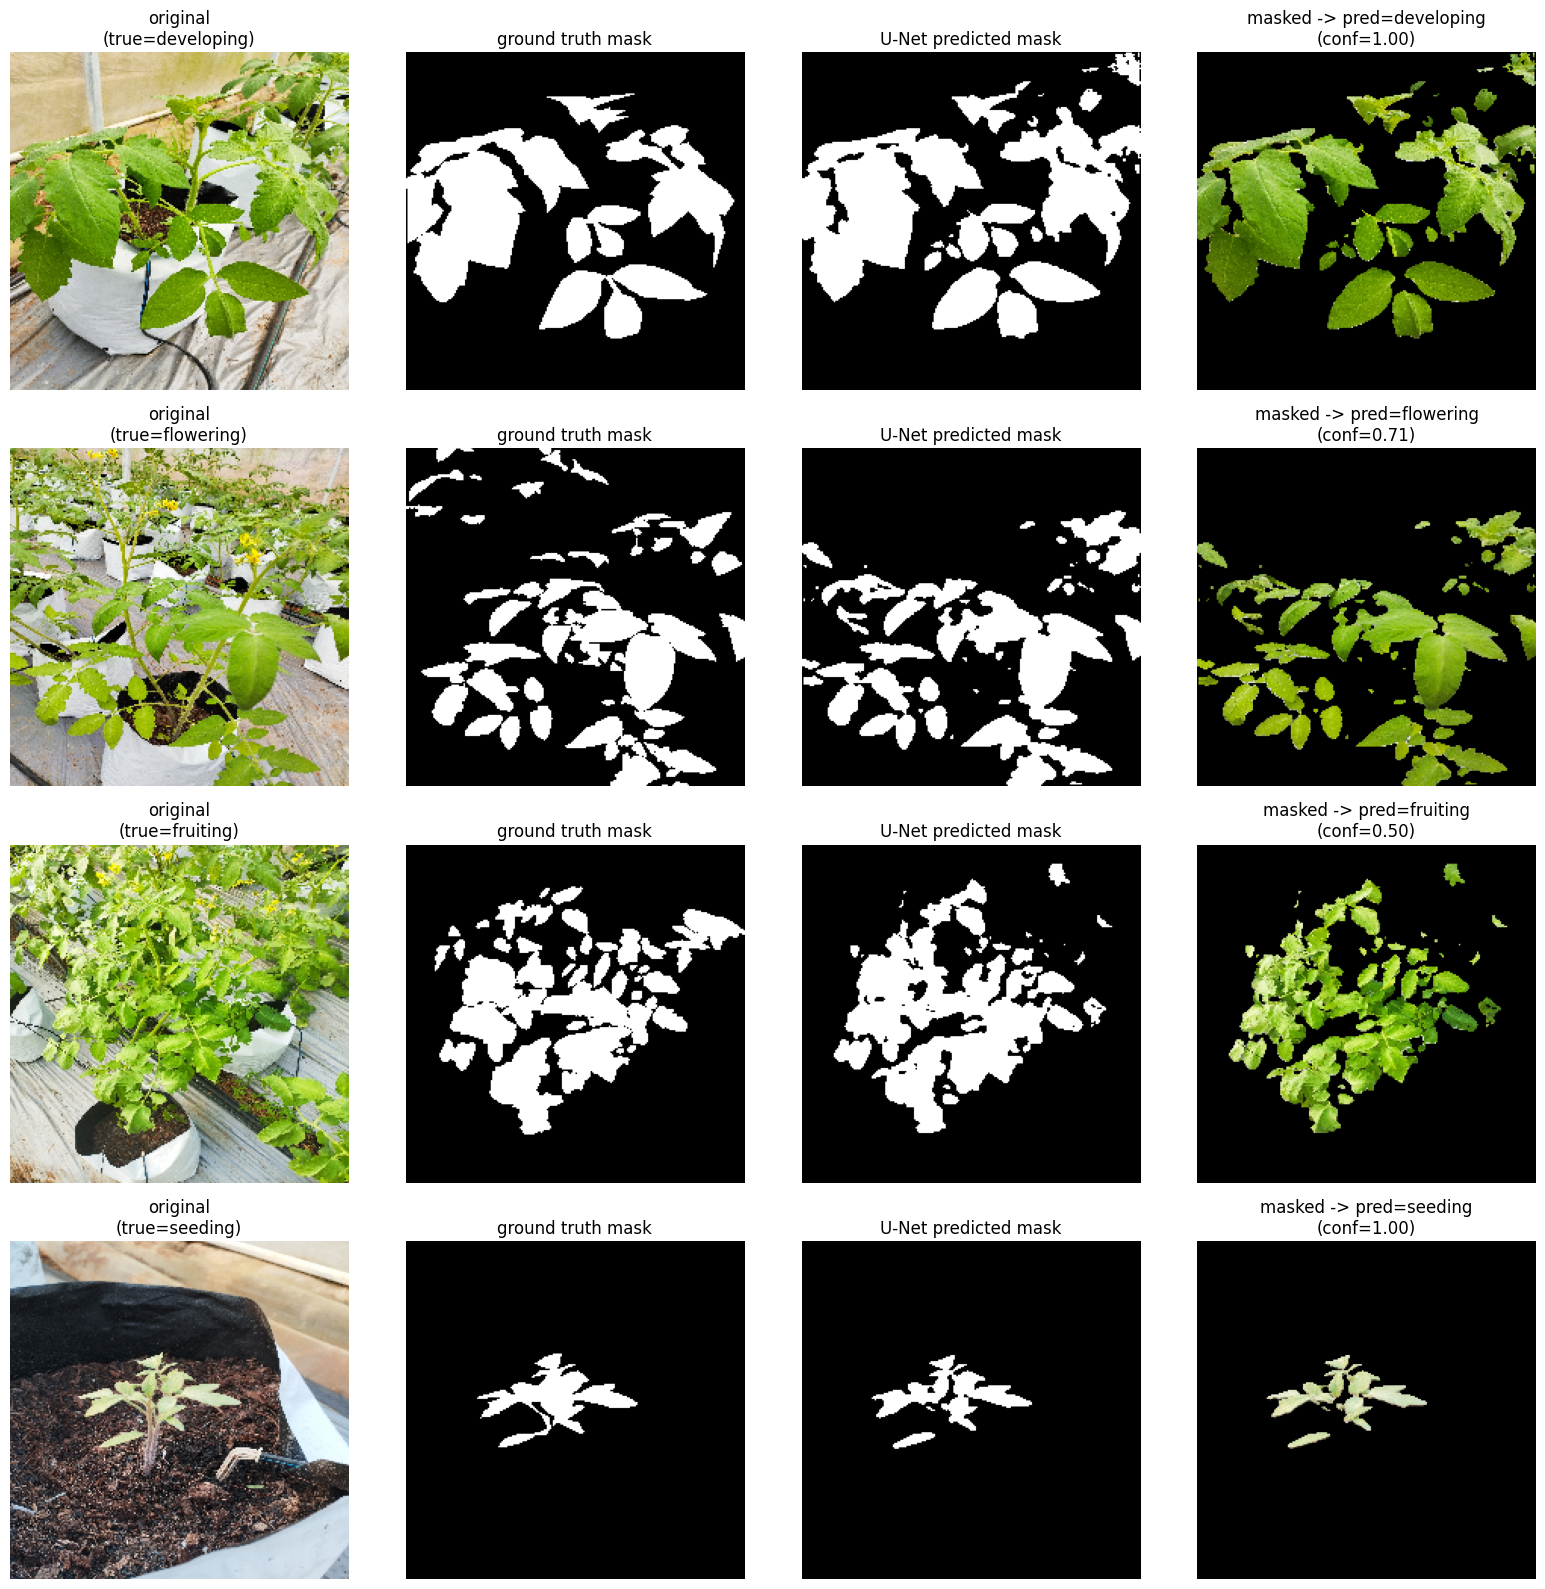

In [11]:
examples = []
seen_classes = set()
for path, cls, image_entry in test_samples:
    if cls in seen_classes:
        continue
    seen_classes.add(cls)
    examples.append((path, cls, image_entry))
    if len(examples) == 4:
        break

fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
for row, (path, true_cls, image_entry) in enumerate(examples):
    pred_label, conf, probs, pred_mask, raw01 = predict_growth_stage(path)
    gt_mask = gt_mask_224(image_entry)
    masked_img = raw01 * pred_mask[..., None]

    axes[row, 0].imshow(raw01); axes[row, 0].set_title(f"original\n(true={true_cls})"); axes[row, 0].axis("off")
    axes[row, 1].imshow(gt_mask, cmap="gray"); axes[row, 1].set_title("ground truth mask"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_mask, cmap="gray"); axes[row, 2].set_title("U-Net predicted mask"); axes[row, 2].axis("off")
    axes[row, 3].imshow(masked_img); axes[row, 3].set_title(f"masked -> pred={pred_label}\n(conf={conf:.2f})"); axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "unet_pipeline_sanity_check.png"), dpi=120)
plt.show()

## Task 3: Full pipeline evaluation on the held-out test set

Runs `predict_growth_stage` on every test image with a matching annotation, compares to
the true class label.

U-Net pipeline test accuracy: 0.7875  (n=160)

              precision    recall  f1-score   support

  developing       0.95      0.95      0.95        41
   flowering       0.89      0.52      0.65        60
    fruiting       0.40      0.86      0.55        21
     seeding       0.97      1.00      0.99        38

    accuracy                           0.79       160
   macro avg       0.80      0.83      0.78       160
weighted avg       0.86      0.79      0.79       160



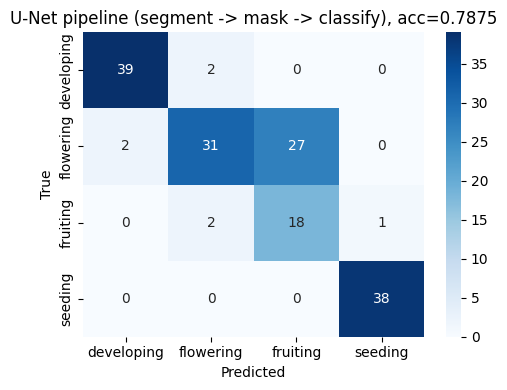

In [12]:
all_preds, all_labels = [], []
for path, cls, image_entry in test_samples:
    pred_label, conf, probs, pred_mask, raw01 = predict_growth_stage(path)
    all_preds.append(pred_label)
    all_labels.append(cls)

pipeline_acc_unet = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"U-Net pipeline test accuracy: {pipeline_acc_unet:.4f}  (n={len(all_labels)})")
print()
print(classification_report(all_labels, all_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES))

cm_unet = confusion_matrix(all_labels, all_preds, labels=CLASS_NAMES)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_unet, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"U-Net pipeline (segment -> mask -> classify), acc={pipeline_acc_unet:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "unet_pipeline_confusion_matrix.png"), dpi=150)
plt.show()

## Reference: DeepLabV3 pipeline's own per-class breakdown (recomputed fresh, same test set)

Uses the exact files in `export_leaf_pipeline/` (no retraining) so the per-class
comparison in Task 4 is apples-to-apples with what's computed above for U-Net.

DeepLabV3 pipeline test accuracy (recomputed here): 0.8438  (originally reported: 0.8500)

              precision    recall  f1-score   support

  developing       0.97      0.88      0.92        41
   flowering       0.81      0.77      0.79        60
    fruiting       0.54      0.71      0.61        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.84       160
   macro avg       0.83      0.84      0.83       160
weighted avg       0.86      0.84      0.85       160



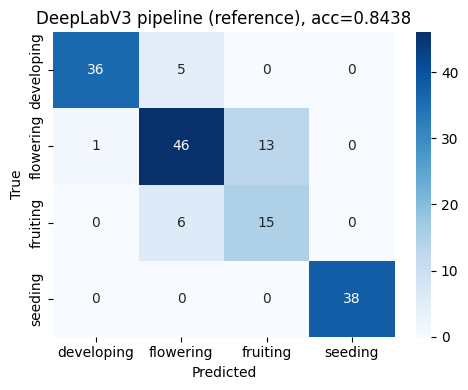

In [13]:
dlv3_clf = models.resnet50(weights=None)
dlv3_clf.fc = nn.Linear(dlv3_clf.fc.in_features, len(CLASS_NAMES))
dlv3_clf_state = torch.load(os.path.join(DEEPLABV3_EXPORT_DIR, "resnet50_leaf_classifier.pth"), map_location=device, weights_only=True)
dlv3_clf.load_state_dict(dlv3_clf_state)
dlv3_clf = dlv3_clf.to(device).eval()

dlv3_raw_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
])

@torch.no_grad()
def predict_growth_stage_dlv3(image_path):
    img = Image.open(image_path).convert("RGB")
    raw = dlv3_raw_transform(img).unsqueeze(0).to(device)
    normed = normalize(raw.squeeze(0)).unsqueeze(0)
    pred_mask = deeplabv3_model(normed)["out"].argmax(dim=1, keepdim=True).float()
    masked_raw = raw * pred_mask
    masked_norm = normalize(masked_raw.squeeze(0)).unsqueeze(0)
    logits = dlv3_clf(masked_norm)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    return CLASS_NAMES[int(probs.argmax())]

dlv3_preds = [predict_growth_stage_dlv3(path) for path, cls, image_entry in test_samples]
dlv3_labels = [cls for path, cls, image_entry in test_samples]
pipeline_acc_dlv3 = np.mean(np.array(dlv3_preds) == np.array(dlv3_labels))

print(f"DeepLabV3 pipeline test accuracy (recomputed here): {pipeline_acc_dlv3:.4f}  "
      f"(originally reported: 0.8500)")
print()
print(classification_report(dlv3_labels, dlv3_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES))

cm_dlv3 = confusion_matrix(dlv3_labels, dlv3_preds, labels=CLASS_NAMES)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dlv3, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"DeepLabV3 pipeline (reference), acc={pipeline_acc_dlv3:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "deeplabv3_pipeline_confusion_matrix_recomputed.png"), dpi=150)
plt.show()

## Task 4: Final comparison table

In [14]:
import csv

comparison_rows = [
    {
        "segmenter": "DeepLabV3-ResNet50",
        "seg_foreground_iou": round(float(np.mean(dlv3_fg_ious)), 4),
        "seg_foreground_dice": round(float(np.mean(dlv3_fg_dices)), 4),
        "seg_both_class_mean_iou": round(float(np.mean(dlv3_both_ious)), 4),
        "pipeline_accuracy": round(float(pipeline_acc_dlv3), 4),
    },
    {
        "segmenter": "U-Net (custom, from scratch)",
        "seg_foreground_iou": round(float(np.mean(unet_fg_ious)), 4),
        "seg_foreground_dice": round(float(np.mean(unet_fg_dices)), 4),
        "seg_both_class_mean_iou": round(float(np.mean(unet_both_ious)), 4),
        "pipeline_accuracy": round(float(pipeline_acc_unet), 4),
    },
]

print(f"{'Segmenter':<28}{'FG IoU':<10}{'FG Dice':<10}{'Both-cls IoU':<15}{'Pipeline Acc':<14}")
for r in comparison_rows:
    print(f"{r['segmenter']:<28}{r['seg_foreground_iou']:<10}{r['seg_foreground_dice']:<10}"
          f"{r['seg_both_class_mean_iou']:<15}{r['pipeline_accuracy']:<14}")

csv_path = os.path.join(PROJECT_ROOT, "unet_vs_deeplabv3_comparison.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(comparison_rows[0].keys()))
    writer.writeheader()
    writer.writerows(comparison_rows)

with open(os.path.join(PROJECT_ROOT, "unet_vs_deeplabv3_comparison.json"), "w", encoding="utf-8") as f:
    json.dump(comparison_rows, f, indent=2)

print(f"\nSaved to {csv_path} and .json")

Segmenter                   FG IoU    FG Dice   Both-cls IoU   Pipeline Acc  
DeepLabV3-ResNet50          0.623     0.7565    0.7507         0.8438        
U-Net (custom, from scratch)0.6646    0.7844    0.7926         0.7875        

Saved to d:\Reasearch\Resnet50test\unet_vs_deeplabv3_comparison.csv and .json


## Which classes struggle for each segmenter? (fruiting/flowering focus)

In [15]:
print(f"{'Class':<12}{'DeepLabV3 FG-IoU':<20}{'U-Net FG-IoU':<16}{'DeepLabV3 pipe F1':<20}{'U-Net pipe F1':<16}")

dlv3_report = classification_report(dlv3_labels, dlv3_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES, output_dict=True)
unet_report = classification_report(all_labels, all_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES, output_dict=True)

for cls in CLASS_NAMES:
    dlv3_fg = np.mean(per_stage_dlv3[cls]["fg_iou"])
    unet_fg = np.mean(per_stage_unet[cls]["fg_iou"])
    dlv3_f1 = dlv3_report[cls]["f1-score"]
    unet_f1 = unet_report[cls]["f1-score"]
    print(f"{cls:<12}{dlv3_fg:<20.4f}{unet_fg:<16.4f}{dlv3_f1:<20.4f}{unet_f1:<16.4f}")

print("\nLook at whether 'fruiting' and 'flowering' are the weakest for BOTH segmenters "
      "(a property of the task/data) or only for one (a property of that specific segmenter).")

Class       DeepLabV3 FG-IoU    U-Net FG-IoU    DeepLabV3 pipe F1   U-Net pipe F1   
developing  0.6883              0.6865          0.9231              0.9512          
flowering   0.5994              0.6307          0.7863              0.6526          
fruiting    0.5059              0.5181          0.6122              0.5455          
seeding     0.6548              0.7755          1.0000              0.9870          

Look at whether 'fruiting' and 'flowering' are the weakest for BOTH segmenters (a property of the task/data) or only for one (a property of that specific segmenter).


## Variant: U-Net fed with DeepLabV3's own preprocessing (Resize+CenterCrop, not its native direct-resize)

Everything above used U-Net's own trained convention (direct resize to 224x224, distorts
aspect ratio). This section instead feeds U-Net the SAME Resize(256)->CenterCrop(224)
image DeepLabV3 uses, so U-Net's predicted mask is applied to the exact same crop
geometry the classifier expects -- removing the alignment mismatch entirely.

**Tradeoff to watch for:** U-Net was *trained* on its own direct-resize convention. Giving
it a center-cropped image instead means U-Net now sees a framing it never saw during
training -- this could hurt its mask quality even as it fixes the alignment problem.
That's exactly why this is measured here rather than assumed either way.

In [16]:
unet_crop_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
])
unet_crop_to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


@torch.no_grad()
def unet_predict_mask_cropped(image_path, threshold=None):
    """Same U-Net model, but fed a Resize+CenterCrop image (DeepLabV3's convention)
    instead of U-Net's own native direct-resize."""
    threshold = threshold if threshold is not None else unet_lpf_extractor.MASK_THRESHOLD
    img = Image.open(image_path).convert("RGB")
    img_cropped = unet_crop_transform(img)
    tensor = unet_crop_to_tensor(img_cropped).unsqueeze(0).to(device)
    logits = unet_model(tensor)
    probs = torch.sigmoid(logits)
    mask = (probs > threshold).float().cpu().squeeze().numpy().astype(np.uint8)
    return mask, img_cropped


unet_crop_fg_ious, unet_crop_fg_dices, unet_crop_both_ious = [], [], []
per_stage_unet_crop = {c: {"fg_iou": [], "fg_dice": [], "both_iou": []} for c in CLASS_NAMES}

for path, cls, image_entry in test_samples:
    pred_mask, _ = unet_predict_mask_cropped(path)
    target_mask = deeplabv3_gt_mask_224(image_entry, IMAGE_SIZE)  # same crop geometry -> same GT helper

    fg_iou, fg_dice = foreground_iou_dice(pred_mask, target_mask)
    both_iou = both_class_mean_iou(pred_mask, target_mask)

    unet_crop_fg_ious.append(fg_iou)
    unet_crop_fg_dices.append(fg_dice)
    unet_crop_both_ious.append(both_iou)
    per_stage_unet_crop[cls]["fg_iou"].append(fg_iou)
    per_stage_unet_crop[cls]["fg_dice"].append(fg_dice)
    per_stage_unet_crop[cls]["both_iou"].append(both_iou)

print("=== U-Net (crop-aligned) segmentation quality (test set) ===")
print(f"Foreground-only IoU:  {np.mean(unet_crop_fg_ious):.4f}   (native-resize variant was {np.mean(unet_fg_ious):.4f})")
print(f"Foreground-only Dice: {np.mean(unet_crop_fg_dices):.4f}   (native-resize variant was {np.mean(unet_fg_dices):.4f})")
print(f"Both-class mean IoU:  {np.mean(unet_crop_both_ious):.4f}   (native-resize variant was {np.mean(unet_both_ious):.4f})")
print()
for cls in CLASS_NAMES:
    d = per_stage_unet_crop[cls]
    print(f"  {cls:<12} fg_iou={np.mean(d['fg_iou']):.4f}  fg_dice={np.mean(d['fg_dice']):.4f}  "
          f"both_iou={np.mean(d['both_iou']):.4f}  n={len(d['fg_iou'])}")

=== U-Net (crop-aligned) segmentation quality (test set) ===
Foreground-only IoU:  0.6674   (native-resize variant was 0.6646)
Foreground-only Dice: 0.7827   (native-resize variant was 0.7844)
Both-class mean IoU:  0.7753   (native-resize variant was 0.7926)

  developing   fg_iou=0.6730  fg_dice=0.7816  both_iou=0.7594  n=41
  flowering    fg_iou=0.6362  fg_dice=0.7696  both_iou=0.7453  n=60
  fruiting     fg_iou=0.4998  fg_dice=0.6318  both_iou=0.6738  n=21
  seeding      fg_iou=0.8031  fg_dice=0.8881  both_iou=0.8962  n=38


U-Net (crop-aligned) pipeline test accuracy: 0.8938  (native-resize variant was 0.7875, DeepLabV3 was 0.8438)

              precision    recall  f1-score   support

  developing       0.95      0.95      0.95        41
   flowering       0.86      0.85      0.86        60
    fruiting       0.68      0.71      0.70        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.89       160
   macro avg       0.87      0.88      0.88       160
weighted avg       0.89      0.89      0.89       160



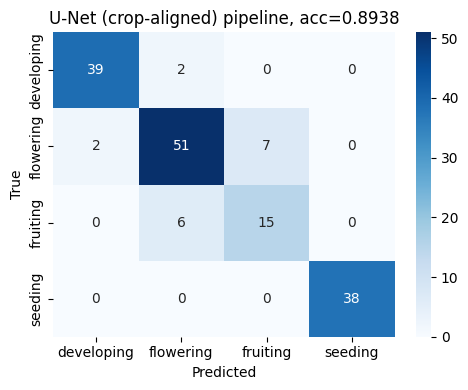

In [17]:
@torch.no_grad()
def predict_growth_stage_unet_cropped(image_path, threshold=None):
    """Crop-aligned variant: U-Net predicts on the Resize+CenterCrop image, mask applied
    to that SAME crop, then classified -- mask and classifier input are geometrically
    aligned by construction, same as the DeepLabV3 pipeline."""
    pred_mask, img_cropped = unet_predict_mask_cropped(image_path, threshold=threshold)
    raw = transforms.ToTensor()(img_cropped).unsqueeze(0).to(device)  # 0-1 scale, unnormalized

    mask_t = torch.from_numpy(pred_mask).float().unsqueeze(0).unsqueeze(0).to(device)
    masked_raw = raw * mask_t
    masked_norm = normalize(masked_raw.squeeze(0)).unsqueeze(0)

    logits = classifier(masked_norm)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx = int(probs.argmax())
    return CLASS_NAMES[pred_idx], float(probs[pred_idx]), dict(zip(CLASS_NAMES, probs.tolist()))


unet_crop_preds, unet_crop_labels = [], []
for path, cls, image_entry in test_samples:
    pred_label, conf, probs = predict_growth_stage_unet_cropped(path)
    unet_crop_preds.append(pred_label)
    unet_crop_labels.append(cls)

pipeline_acc_unet_crop = np.mean(np.array(unet_crop_preds) == np.array(unet_crop_labels))
print(f"U-Net (crop-aligned) pipeline test accuracy: {pipeline_acc_unet_crop:.4f}  "
      f"(native-resize variant was {pipeline_acc_unet:.4f}, DeepLabV3 was {pipeline_acc_dlv3:.4f})")
print()
print(classification_report(unet_crop_labels, unet_crop_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES))

cm_unet_crop = confusion_matrix(unet_crop_labels, unet_crop_preds, labels=CLASS_NAMES)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_unet_crop, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"U-Net (crop-aligned) pipeline, acc={pipeline_acc_unet_crop:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "unet_crop_aligned_pipeline_confusion_matrix.png"), dpi=150)
plt.show()

## Task 4 (updated): three-way comparison table

Adds the crop-aligned U-Net variant to the table built earlier.

In [18]:
comparison_rows_v2 = comparison_rows + [{
    "segmenter": "U-Net (crop-aligned, DeepLabV3-style preprocessing)",
    "seg_foreground_iou": round(float(np.mean(unet_crop_fg_ious)), 4),
    "seg_foreground_dice": round(float(np.mean(unet_crop_fg_dices)), 4),
    "seg_both_class_mean_iou": round(float(np.mean(unet_crop_both_ious)), 4),
    "pipeline_accuracy": round(float(pipeline_acc_unet_crop), 4),
}]

print(f"{'Segmenter':<48}{'FG IoU':<10}{'FG Dice':<10}{'Both-cls IoU':<15}{'Pipeline Acc':<14}")
for r in comparison_rows_v2:
    print(f"{r['segmenter']:<48}{r['seg_foreground_iou']:<10}{r['seg_foreground_dice']:<10}"
          f"{r['seg_both_class_mean_iou']:<15}{r['pipeline_accuracy']:<14}")

print()
if pipeline_acc_unet_crop > pipeline_acc_unet:
    print(f"Crop-aligned preprocessing IMPROVED U-Net's pipeline accuracy: "
          f"{pipeline_acc_unet:.4f} -> {pipeline_acc_unet_crop:.4f} "
          f"({pipeline_acc_unet_crop - pipeline_acc_unet:+.4f})")
else:
    print(f"Crop-aligned preprocessing did NOT improve U-Net's pipeline accuracy: "
          f"{pipeline_acc_unet:.4f} -> {pipeline_acc_unet_crop:.4f} "
          f"({pipeline_acc_unet_crop - pipeline_acc_unet:+.4f})")
if np.mean(unet_crop_fg_ious) < np.mean(unet_fg_ious):
    print(f"...at the cost of segmentation quality: FG IoU {np.mean(unet_fg_ious):.4f} -> "
          f"{np.mean(unet_crop_fg_ious):.4f} (U-Net is seeing a framing it wasn't trained on)")

csv_path_v2 = os.path.join(PROJECT_ROOT, "unet_vs_deeplabv3_comparison_v2.csv")
with open(csv_path_v2, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(comparison_rows_v2[0].keys()))
    writer.writeheader()
    writer.writerows(comparison_rows_v2)
with open(os.path.join(PROJECT_ROOT, "unet_vs_deeplabv3_comparison_v2.json"), "w", encoding="utf-8") as f:
    json.dump(comparison_rows_v2, f, indent=2)
print(f"\nSaved to {csv_path_v2} and .json")

Segmenter                                       FG IoU    FG Dice   Both-cls IoU   Pipeline Acc  
DeepLabV3-ResNet50                              0.623     0.7565    0.7507         0.8438        
U-Net (custom, from scratch)                    0.6646    0.7844    0.7926         0.7875        
U-Net (crop-aligned, DeepLabV3-style preprocessing)0.6674    0.7827    0.7753         0.8938        

Crop-aligned preprocessing IMPROVED U-Net's pipeline accuracy: 0.7875 -> 0.8938 (+0.1063)

Saved to d:\Reasearch\Resnet50test\unet_vs_deeplabv3_comparison_v2.csv and .json


## Task 5: Export -- NOT automatic

This cell is intentionally left as a decision point, not auto-run. After reviewing the
Task 3/4 results above, tell me whether to export this U-Net pipeline to
`export_leaf_pipeline_unet/` (mirroring `export_leaf_pipeline/`'s structure: two `.pth`
files, `metadata.json`, a `leaf_pipeline.py` exposing `predict_growth_stage()`). I will
only build that folder if you confirm -- same as how the masked-only classifier
experiment was correctly left unexported when it didn't generalize.

In [19]:
# ==== Test accuracy summary: U-Net (crop-aligned) pipeline ====
print("=== U-Net (crop-aligned) segmentation quality -- TEST SET ===")
print(f"Foreground-only IoU:  {np.mean(unet_crop_fg_ious):.4f}")
print(f"Foreground-only Dice: {np.mean(unet_crop_fg_dices):.4f}")
print(f"Both-class mean IoU:  {np.mean(unet_crop_both_ious):.4f}")
print()
for cls in CLASS_NAMES:
    d = per_stage_unet_crop[cls]
    print(f"  {cls:<12} fg_iou={np.mean(d['fg_iou']):.4f}  fg_dice={np.mean(d['fg_dice']):.4f}  "
          f"both_iou={np.mean(d['both_iou']):.4f}  n={len(d['fg_iou'])}")

print("\n=== U-Net (crop-aligned) full pipeline accuracy -- TEST SET ===")
print(f"Test accuracy: {pipeline_acc_unet_crop:.4f}  (n={len(unet_crop_labels)})")
print()
print(classification_report(unet_crop_labels, unet_crop_preds, labels=CLASS_NAMES, target_names=CLASS_NAMES))

print("=== For reference, all three pipelines' TEST accuracy ===")
print(f"DeepLabV3:              {pipeline_acc_dlv3:.4f}")
print(f"U-Net (native resize):  {pipeline_acc_unet:.4f}")
print(f"U-Net (crop-aligned):   {pipeline_acc_unet_crop:.4f}   <- current recommended pipeline")


=== U-Net (crop-aligned) segmentation quality -- TEST SET ===
Foreground-only IoU:  0.6674
Foreground-only Dice: 0.7827
Both-class mean IoU:  0.7753

  developing   fg_iou=0.6730  fg_dice=0.7816  both_iou=0.7594  n=41
  flowering    fg_iou=0.6362  fg_dice=0.7696  both_iou=0.7453  n=60
  fruiting     fg_iou=0.4998  fg_dice=0.6318  both_iou=0.6738  n=21
  seeding      fg_iou=0.8031  fg_dice=0.8881  both_iou=0.8962  n=38

=== U-Net (crop-aligned) full pipeline accuracy -- TEST SET ===
Test accuracy: 0.8938  (n=160)

              precision    recall  f1-score   support

  developing       0.95      0.95      0.95        41
   flowering       0.86      0.85      0.86        60
    fruiting       0.68      0.71      0.70        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.89       160
   macro avg       0.87      0.88      0.88       160
weighted avg       0.89      0.89      0.89       160

=== For reference, all three pipelines' TEST a